# Line Tracing —— CV 1&2&3 Summary

## 阶段一：预处理 (Preprocessing)

1. 灰度化 (Grayscale)​​

    - ​​作用​​：将彩色的RGB图像转换为单通道的灰度图像。

    - ​​输出​​：一个二维矩阵，每个像素点只有一个强度值（Intensity），范围是0-255。白色是255，黑色是0，故gradient从黑色指向白色。
  
2. 梯度
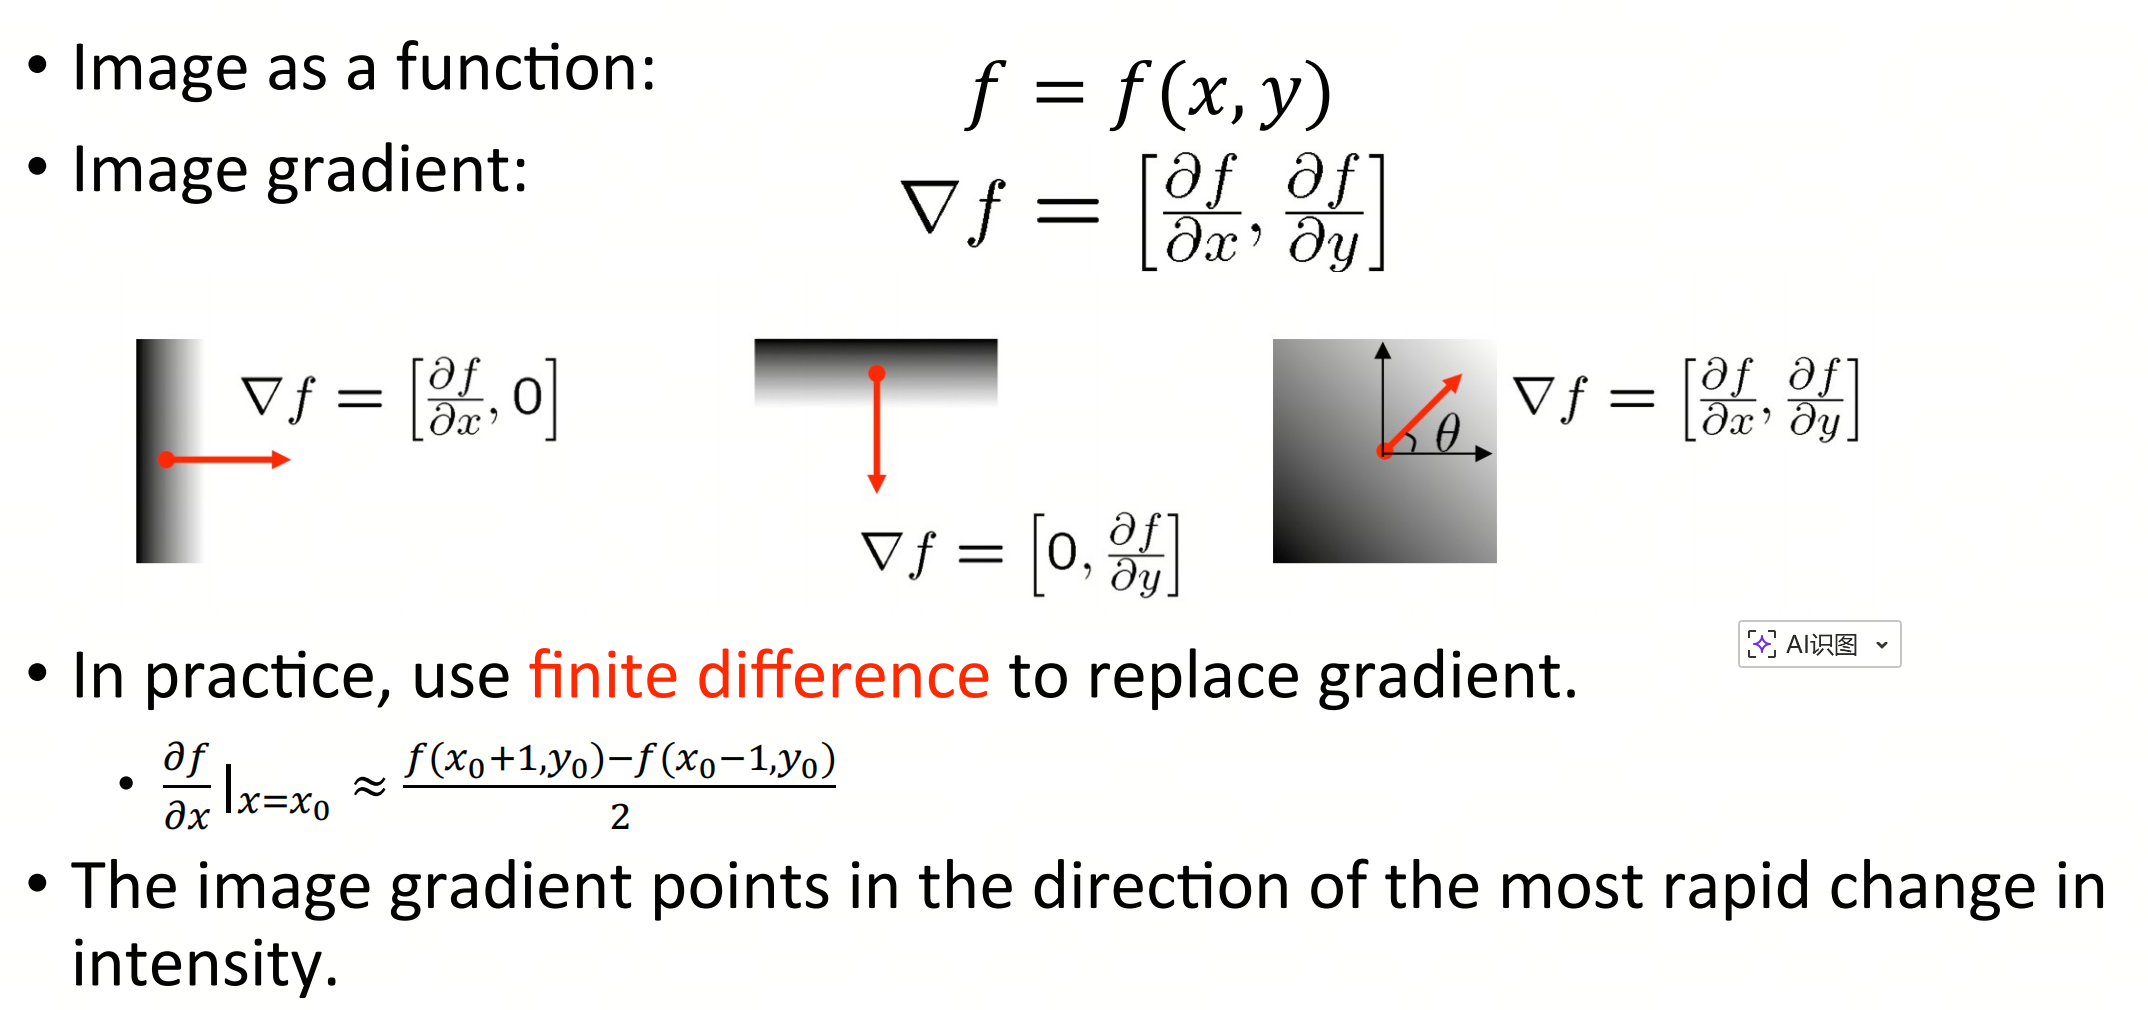
Gradient magnitude: $ \|\nabla f\| = \sqrt{\left(\frac{\partial f}{\partial x}\right)^2 + \left(\frac{\partial f}{\partial y}\right)^2} $
3. ​​高斯滤波 (Gaussian Filtering) 

    - ​​作用​​：​​降噪​​。原始图像中可能存在噪点，这些噪点在后续的边缘检测中会被误认为是“边缘”，导致结果不准确。高斯模糊通过卷积运算，将每个像素点的值与其周围像素点的值进行加权平均，从而平滑图像、抑制噪声。但也可能造成distortion扭曲。
    - 具体实现：参见作业convolve

滤波就是**挑选频率**：
*   **低通滤波（Low-pass Filter）**：只让低频通过，把高频切掉。
    *   *效果*：去掉了边缘和噪点，图像变**模糊**了（因为细节没了）。
*   **高通滤波（High-pass Filter）**：只让高频通过，把低频切掉。
    *   *效果*：去除了背景，只留下了边缘，图像看起来像**素描**。

**高斯滤波，本质上就是一个“低通滤波器”。** 它的目的是让图像变平滑（去噪、模糊）。

---

### 高斯函数

高斯滤波的核心是一个**高斯核（Gaussian Kernel）**，它的形状就是著名的**钟形曲线（Bell Curve）**。

在一维情况下，公式长这样：
$$ g(x) = \frac{1}{\sqrt{2\pi}\sigma} e^{-\frac{x^2}{2\sigma^2}} $$

关注参数 **$\sigma$ (标准差)**。

#### $\sigma$ 在空间域（图像上）的直观意义：
$\sigma$ 控制着这个钟形曲线的**胖瘦**。
*   **$\sigma$ 很大**：钟形曲线很**胖**、很**平**。
    *   这意味着滤波时会把周围很远的像素都加权平均进来。
    *   *结果*：图像变得**非常模糊**。
*   **$\sigma$ 很小**：钟形曲线很**瘦**、很**尖**。
    *   这意味着滤波时只关注中心像素，周围像素影响很小。
    *   *结果*：图像**几乎不变**。
*   **$\sigma \to 0$**：曲线变成一根针（狄拉克 $\delta$ 函数）。
    *   *结果*：完全不变，相当于没滤波。

#### $\sigma$ 对频域的影响

这里是整个问题的难点，也是傅里叶变换最神奇的地方。

1. 傅里叶变换的“不确定性原理”
傅里叶变换有一个铁律：**空间域越宽，频率域越窄；空间域越窄，频率域越宽。**
这就像捏橡皮泥：你把一头捏宽了，另一头必然变窄。总量是守恒的。

数学上有一个完美的性质：**高斯函数的傅里叶变换，依然是一个高斯函数。**

如果空间域的高斯宽度是 $\sigma$，那么频率域的高斯宽度大约是 $1/\sigma$（成反比）。

2. 场景一：$\sigma$ 越大（空间域很胖）
*   **空间域**：曲线很胖，模糊能力强。
*   **频率域**：根据反比关系，频率域的曲线会变得**很瘦、很窄**。
*   **什么是“频域 sharp"？**
    *   这里的 "sharp" 不是指图像清晰，而是指**频率响应曲线的形状很尖锐**。
    *   它像一个细长的尖峰，只集中在频率为 0 的地方（直流分量/低频）。
    *   稍微有点频率（高频），曲线的高度就迅速掉到 0 了。
*   **结论**：因为频率域的曲线很窄（sharp），它**只允许极低频通过**，把稍微高一点的频率都拦住了。
    *   *对应效果*：高频分量（细节、噪点）无法通过 $\rightarrow$ 图像 сильно 模糊。

3. 场景二：$\sigma$ 越小，趋于 0（空间域很瘦）
*   **空间域**：曲线变成一根针（几乎不模糊）。
*   **频率域**：根据反比关系，频率域的曲线会变得**非常宽、非常平**。
*   **极限情况 $\sigma \to 0$**：
    *   空间域是 $\delta$ 函数（脉冲）。
    *   频率域变成了一条**水平直线**，高度为 1（常数）。
    *   公式表达：$F(g) = 1$。
*   **结论**：频率域是一条平线，意味着**所有频率（从低到高）的通过比例都是 1**。
    *   *对应效果*：没有任何频率被衰减 $\rightarrow$ **根本不滤波**，原图输出。

| 参数 $\sigma$ | 空间域形状 (图像上) | 频率域形状 (频谱上) | 对高频的影响 | 最终图像效果 |
| :--- | :--- | :--- | :--- | :--- |
| **很大** | 胖、平 (宽) | **瘦、尖 (Sharp/Narrow)** | **阻断** (通过极少) | 非常模糊 |
| **中等** | 适中 | 适中 | 部分衰减 | 适度平滑 |
| **趋近 0** | 针尖 (窄) | **平、宽 (Flat/Wide)** | **全通** ($F(g)=1$) | 原图 (无滤波) |

## 阶段二：边缘检测 (Edge Detection)

Definition: An edge is defined as a region in the image where there is a “significant”
change in the pixel intensity values (or having high contrast) along one
direction in the image, and almost no changes in the pixel intensity values
(or low contrast) along its orthogonal direction.

1. ​​计算梯度 (Gradient Calculation)

    - ​​作用​​：找到图像中亮度变化最剧烈的点，这些点就是潜在的边缘。

    - ​​如何实现​​：使用边缘检测算子（如Sobel）与图像进行​​卷积​​。​​这个卷积核的设计目的不再是模糊，而是求差分（近似求导）​​。基于Derivative Theorem:
    $$
    \frac{d}{dx}(f * g) = f * \frac{d}{dx}g
    $$
    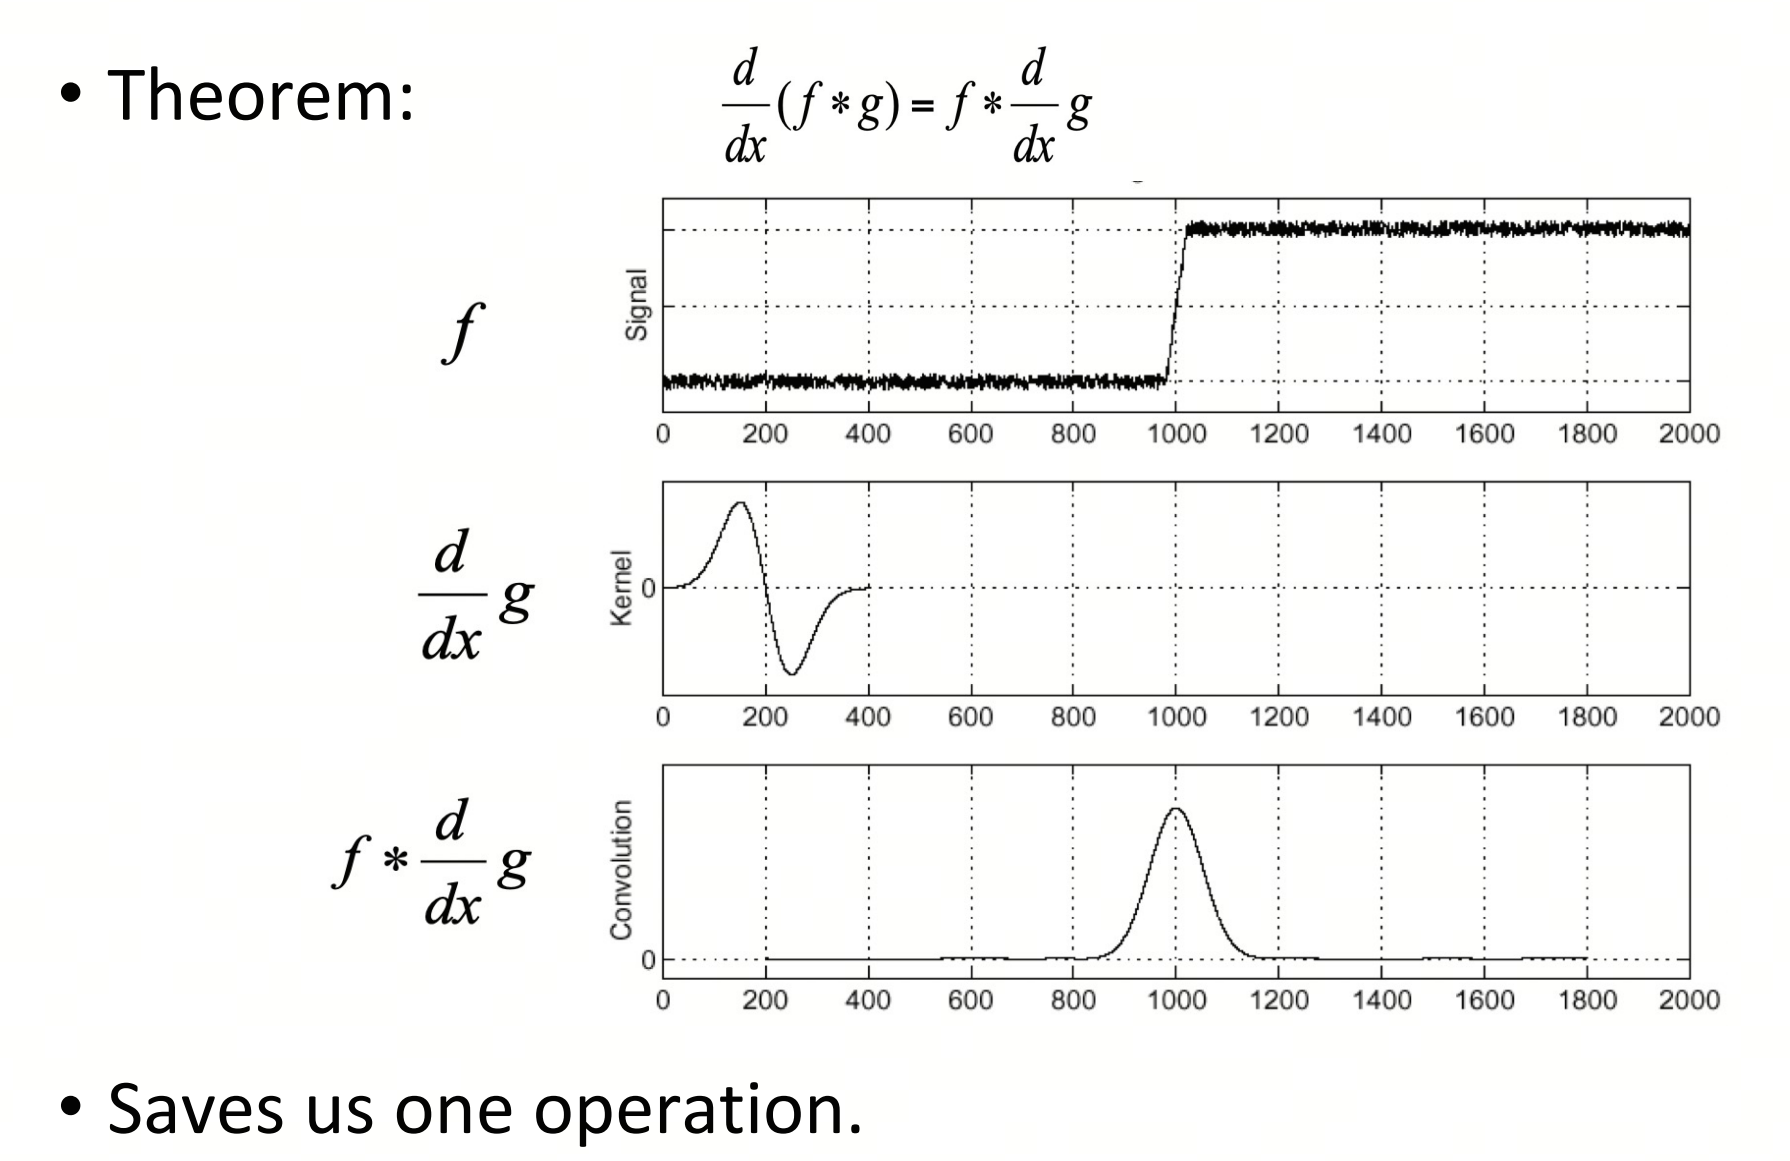

直到这一步，才真正计算了梯度。前面预处理阶段使用的确实是原始强度值（Intensity）。后续所有步骤都是基于梯度信息，而不是原始强度值。

2. ​​非极大值抑制 (Non-Maximum Suppression, NMS)​​

    - ​​作用​​：​​细化边缘​​。经过梯度计算后，边缘可能是一片粗粗的一条区域。NMS的目的是只保留每个边缘中心点（梯度值最大的点），抑制掉周围非最大的点，从而将“粗边缘”细化成“单像素宽”的精准边缘。

    - 和梯度的联系：​​必须同时使用模和方向​​！NMS的目的是细化边缘，它的做法是：沿着当前像素点的​​梯度方向​​去查看它的两个邻居像素。只有当当前像素的模​​大于​​这两个邻居的模时，它才被保留；否则就被抑制。这样就能确保只留下梯度方向上的极大值，从而得到细化的边缘。如果不知道方向，就无法确定要比较哪两个邻居。

    - 通过双线性插值计算可能不在格点上的邻居的值：
    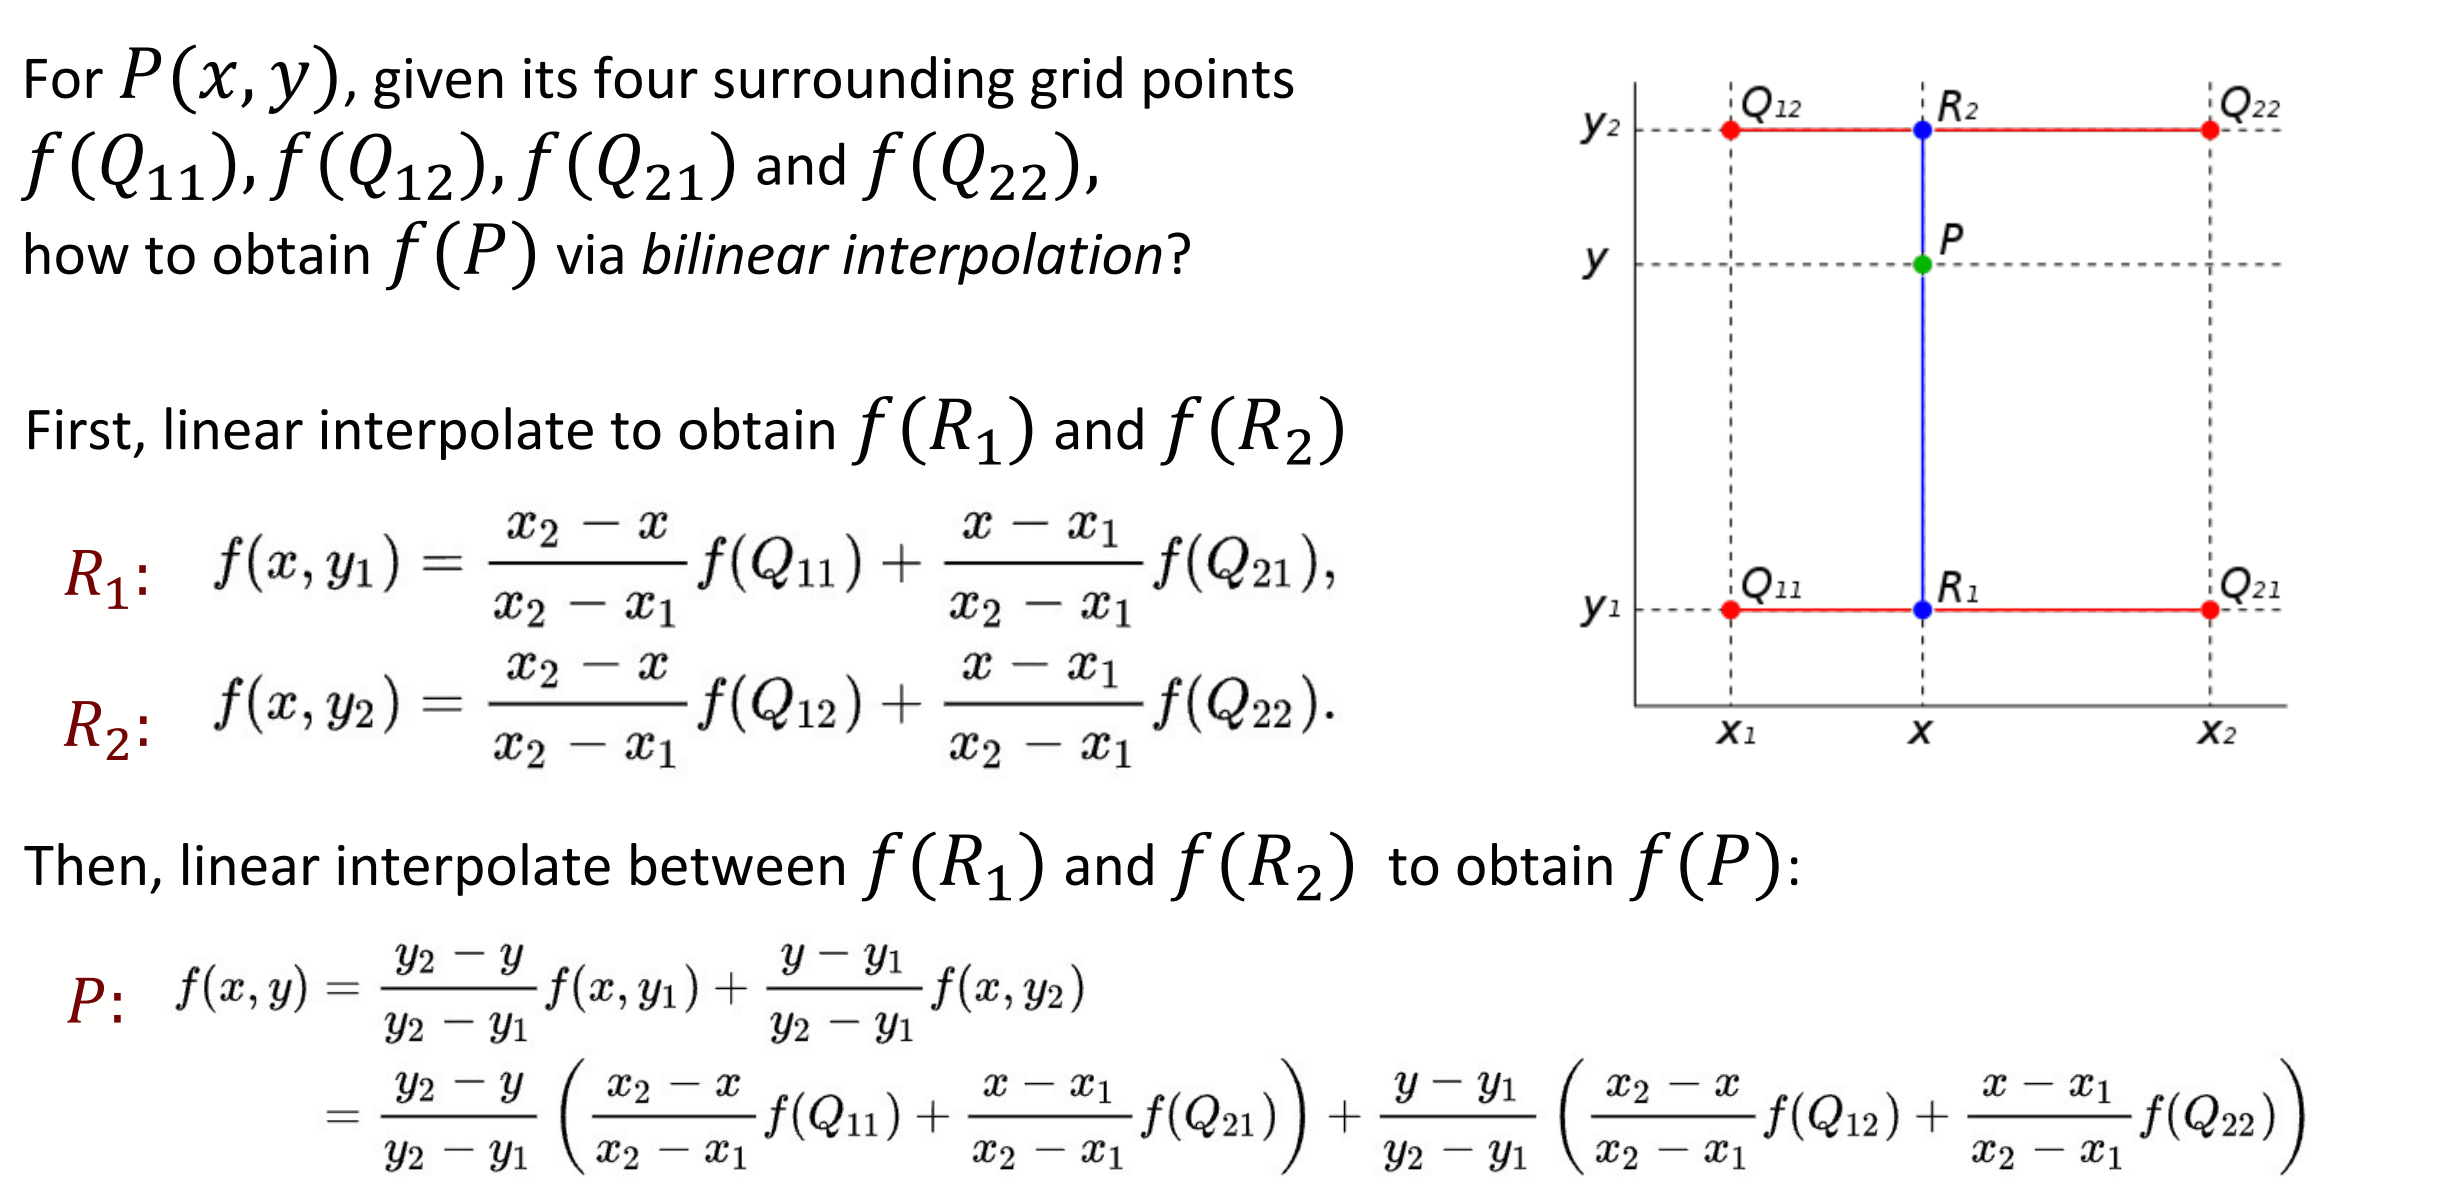 

    - 简化版：把gradient的方法离散化，只分成上下左右，左上左下右上右下。
    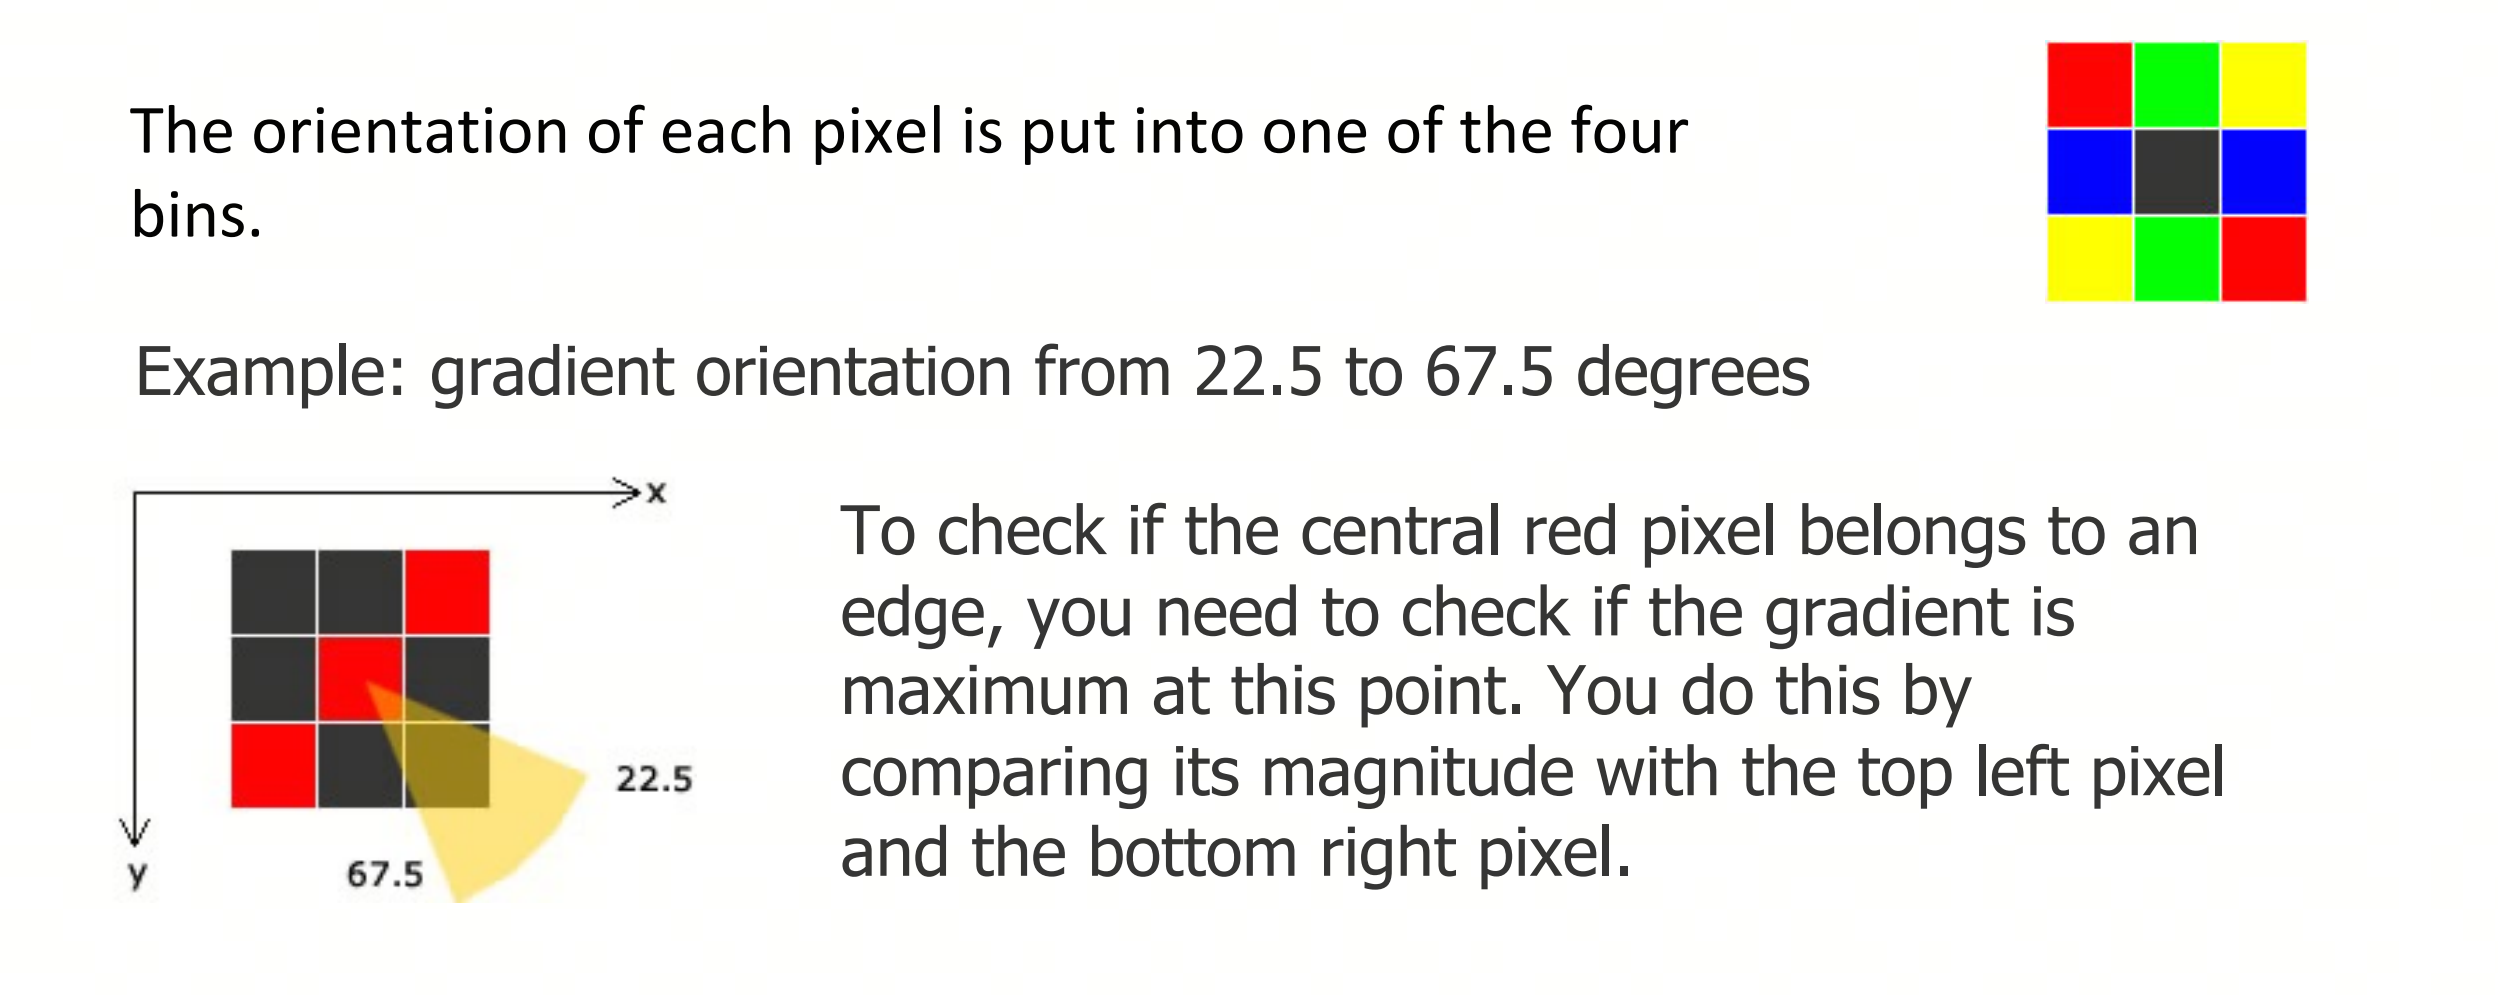

3. ​​滞后阈值与边缘连接 (Hysteresis Thresholding & Edge Linking)​​

    - ​​作用​​：​连线，​确定真正的边缘​​。主要看​梯度的​模​​。用模的大小来判断这是强边缘、弱边缘还是非边缘。通过设置一高一低两个阈值，将梯度值分为三类：

        a. 强边缘（高于高阈值）：肯定是边缘。

        b. 弱边缘（介于高低阈值之间）：可能是边缘，也可能是噪声。

        c. 非边缘（低于低阈值）：肯定不是边缘。

    - ​​边缘连接​​：检查弱边缘像素，如果它与强边缘像素相连，就将其保留为真正的边缘；如果不相连，则认为是噪声并将其抑制。这一步确保了边缘的连续性。

4. 评价标准
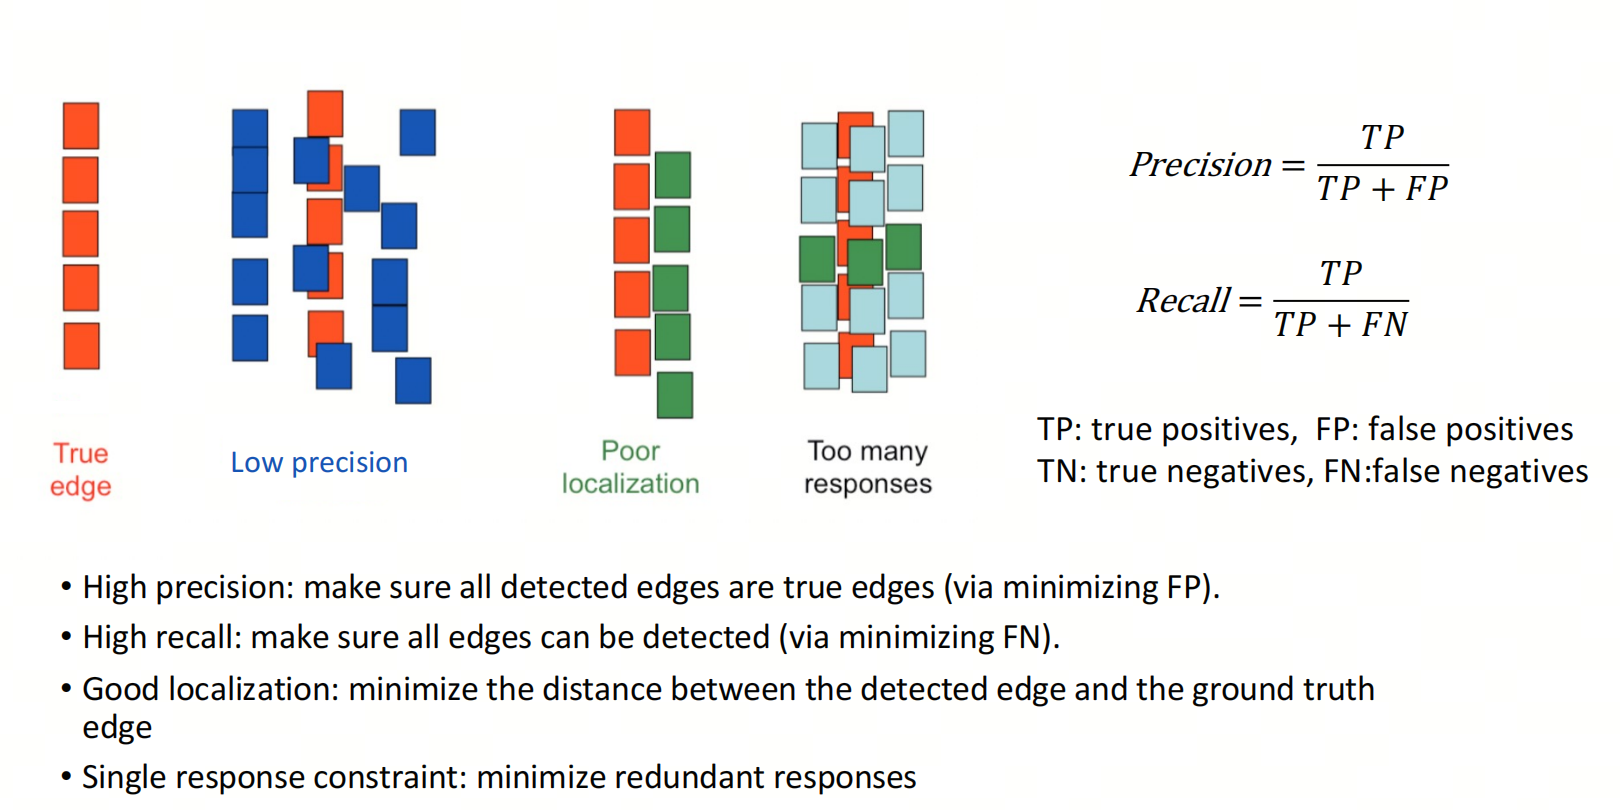
recall：召回，主要看有没有没检测出来的  
precision：精度，主要看检测出来的是不是正确的

## 阶段三：车道线拟合 (Line Fitting)

经过阶段二，我们得到了一张​​二值图（Binary Image）​​，图中黑色的点就是被检测出的所有边缘点。现在我们需要从这些散乱的点中找出符合直线形状的点集（即车道线）。

### ​​RANSAC (Random Sample Consensus)​​

- ​​作用​​：​​鲁棒地拟合模型，排除噪声（异常点）的干扰​​。

- ​​为什么需要它​​：在边缘二值图中，除了车道线点，肯定还存在很多噪声点。直接用最小二乘法拟合，这些噪声点会严重影响拟合结果，导致直线位置偏离。

- ​​如何工作​​：RANSAC通过随机抽取少量点来拟合一个模型（如两点确定一条直线），然后计算有多少其他点符合这个模型（即内点 - inliers）。这个过程重复多次，最终选择拥有最多内点的那个模型。它​​能有效地忽略掉那些不符合主流趋势的噪声点​outlier​，得到非常鲁棒和准确的拟合结果。

- ​​与SVD的关系​​：RANSAC不是替代SVD，而是与它协同工作。​​通常的流程是：用RANSAC从一堆点（可能包含噪声）中找出哪些点是内点（真正的车道线点），然后针对找出的这批“干净的内点”，使用SVD/最小二乘法进行最终精确的直线拟合。    
​​
- 特别说明：RANSAC中的假设可以并行计算，避开loop

* ​霍夫变换 (Hough Transform)​​ 和 ​​RANSAC​​ 是 ​​竞争/替代​​ 关系。通常会选择其中一种来从边缘点中初步找出候选直线。注：霍夫变换本身通过寻找参数空间的峰值直接给出了模型参数，通常不再需要SVD细化。但RANSAC之后则非常需要。

#### 算法核心推导

**如何计算我们需要随机采样多少次（$N$），才能保证大概率（$p$）找到一组纯由内点（Inliers）组成的样本。**

##### 第一部分：公式 $N$ 的推导逻辑

推导的核心在于概率论中的**对立事件**。

1.  **定义基本概率：**
    *   $e$ 是外点率（outlier ratio），即数据集中坏点的比例。
    *   那么，$1 - e$ 就是**内点率**（inlier ratio），即随机选一个点是好点的概率。

2.  **单次采样成功的概率：**
    *   我们要拟合一个模型，最少需要 $s$ 个点（例如拟合直线需要 $s=2$）。
    *   我们要选出的这 $s$ 个点**全都是内点**，模型才能拟合正确。
    *   假设数据量足够大，每次采样近似独立，那么一次采样中，$s$ 个点全是内点的概率 $w$ 为：
        $$ w = (1 - e) \times (1 - e) \times \dots \times (1 - e) = (1 - e)^s $$

3.  **单次采样失败的概率：**
    *   只要这 $s$ 个点里**混入了至少一个外点**，这次采样就是失败的。
    *   失败概率 = $1 - \text{成功概率}$
    *   $$ P(\text{fail}) = 1 - w = 1 - (1 - e)^s $$

4.  **$N$ 次采样全部失败的概率：**
    *   如果我们采样了 $N$ 次，每一次都倒霉，全都混入了外点（即 $N$ 次全部失败）。
    *   $$ P(\text{all fail}) = (P(\text{fail}))^N = (1 - (1 - e)^s)^N $$

5.  **建立方程求解 $N$：**
    *   我们的目标是：在 $N$ 次采样中，**至少有一次成功**（选出纯内点集）的概率要达到 $p$（例如 99%）。
    *   “至少有一次成功”的对立事件正是“$N$ 次全部失败”。
    *   所以：
        $$ p = 1 - P(\text{all fail}) $$
        $$ p = 1 - (1 - (1 - e)^s)^N $$
    *   移项整理：
        $$ 1 - p = (1 - (1 - e)^s)^N $$
    *   两边同时取对数（$\log$）：
        $$ \log(1 - p) = N \cdot \log(1 - (1 - e)^s) $$
    *   最终得到 PPT 中的公式：
        $$ N = \frac{\log(1 - p)}{\log(1 - (1 - e)^s)} $$

##### 第二部分：为什么要用尽可能少的点（$s$ 越小越好）？

根据上面的公式和 PPT 中的表格，我们可以清楚地看到 **$s$（最小采样点数）对计算量 $N$ 有着指数级的影响。**

**1. 数学上的解释：**
请看分母中的项 $(1 - e)^s$。
*   因为 $e$ 是外点率（比如 0.5），所以 $(1-e)$ 是一个小于 1 的正数（比如 0.5）。
*   当 $s$ 增大时，$(1-e)^s$ 会**急剧减小**（指数衰减）。
*   这导致分母 $\log(1 - \text{很小的数})$ 的绝对值变得非常小。
*   分母越小，整个分数 $N$ 就会变得**巨大**。

**2. 结合 PPT 表格的直观解释：**
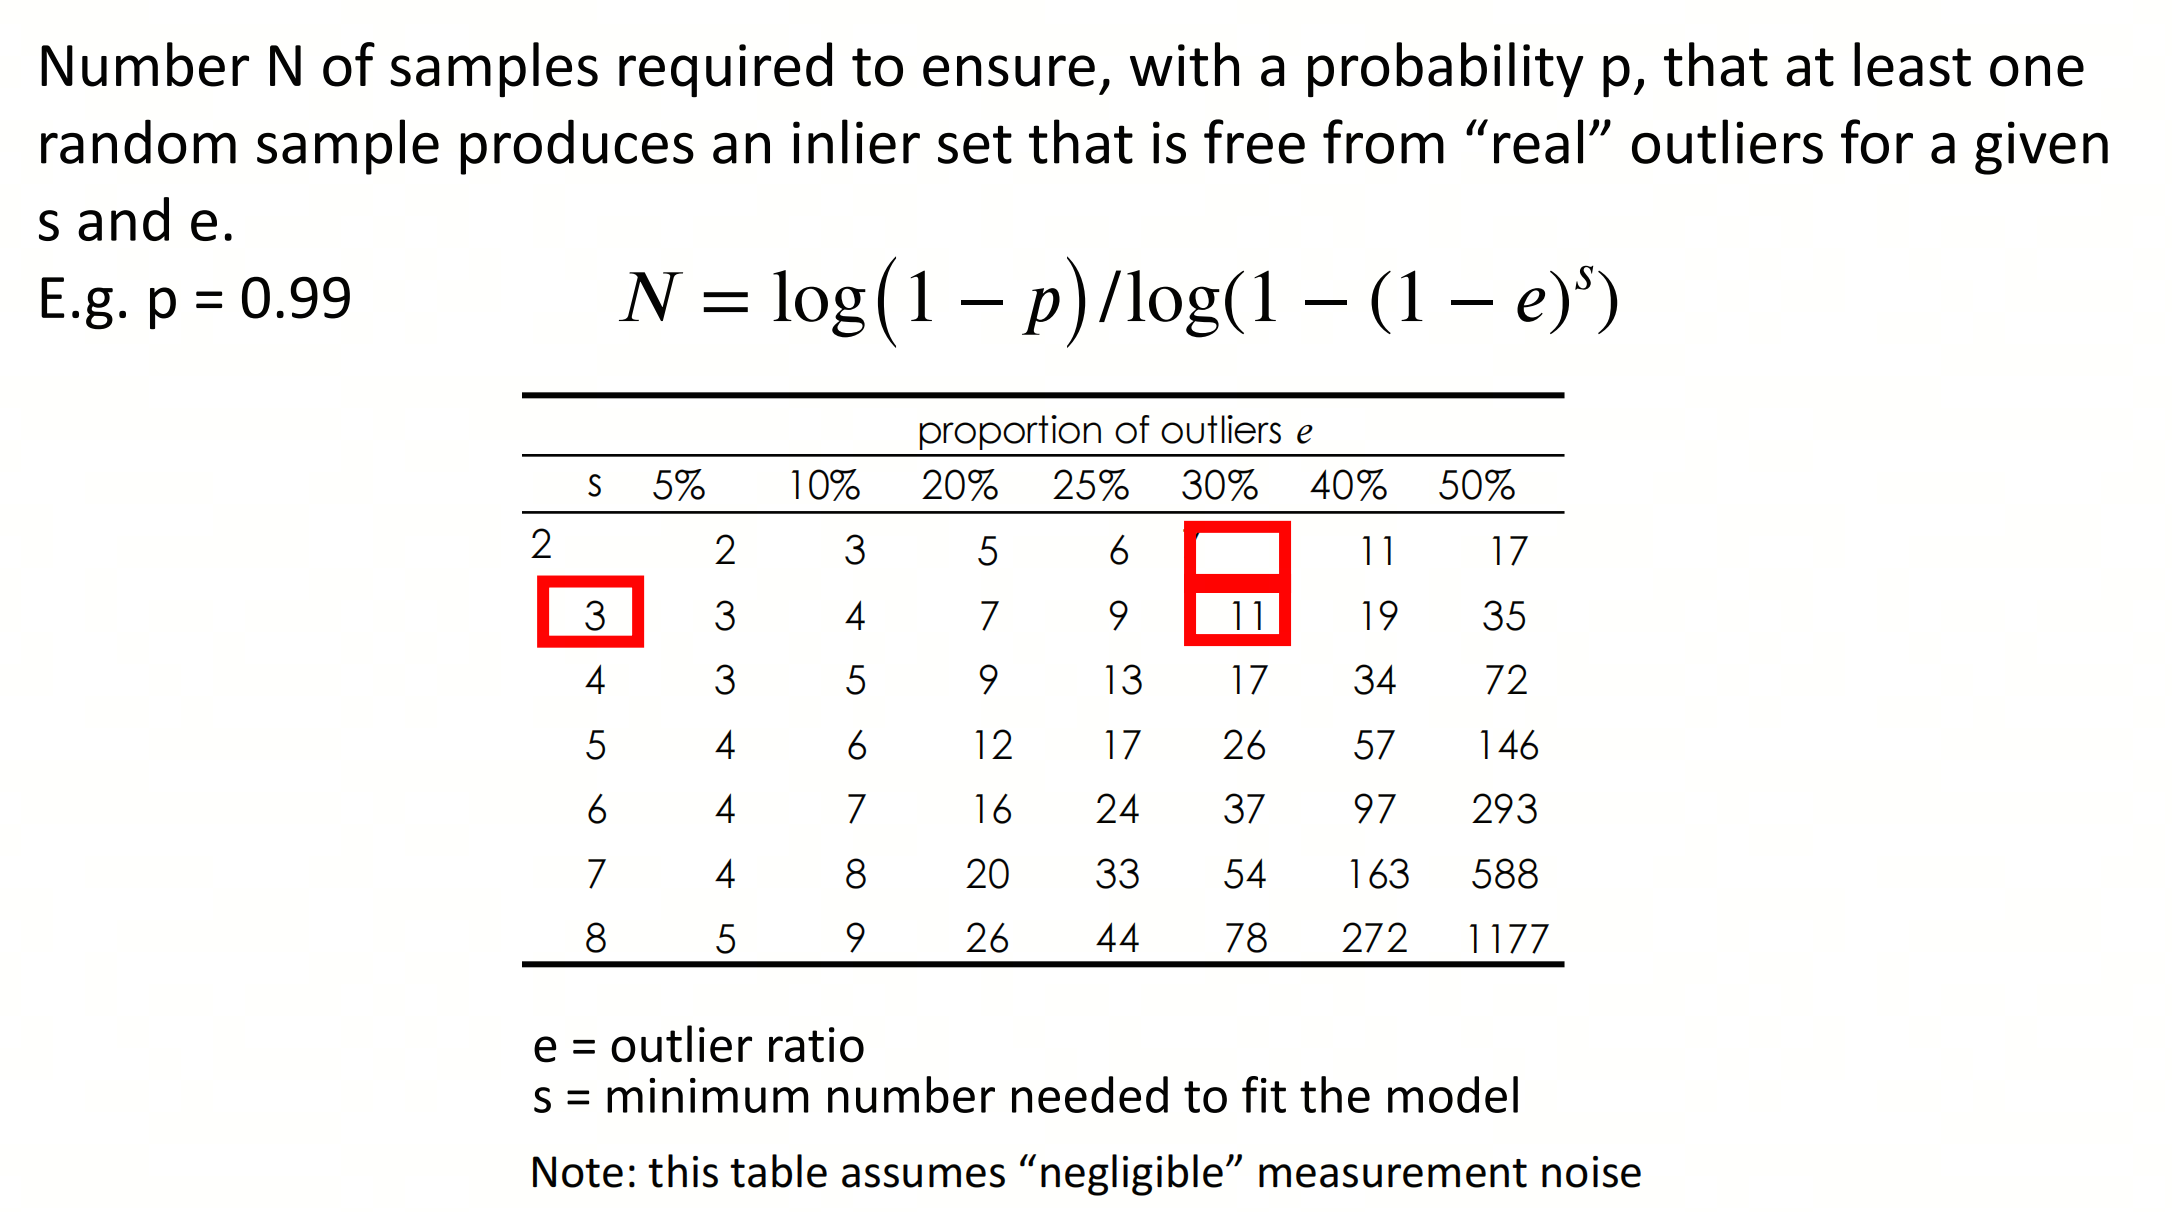
请看 PPT 表格中最右侧的一列（假设外点率高达 50%，即数据很脏）：
*   **当 $s=2$ 时（拟合直线）：** $N = 17$。
    *   你只需要随机试 17 次，就有 99% 的把握找到两个纯内点。
*   **当 $s=3$ 时（拟合圆或平面）：** $N = 35$。
    *   点数加 1 个，采样次数翻倍。
*   **当 $s=8$ 时（例如拟合基础矩阵 Fundamental Matrix）：** $N = 1177$。
    *   采样次数爆炸到了 1000 多次！

**3. 结论：**
RANSAC 算法的核心原则之一就是**使用最小样本集（Minimal Sample Set）**。
*   如果我们能用 2 个点确定一条直线，就绝对不要用 3 个点去拟合（虽然 3 个点也能拟合，但那是过约束，且会导致 $s$ 变大，计算量剧增）。
*   **$s$ 越小，我们在充满噪声（Outliers）的数据中“撞大运”选到全内点组合的概率就越大，所需的采样次数 $N$ 就越少，算法就越快。**

### ​最小二乘法 (Least Squares) / SVD​​

- ​​作用​​：​​从边缘点中拟合出直线方程​​。这是最直观的拟合方法。

- ​​最小二乘法/SVD​​：如果你已经有一组确信是属于同一条直线的点（比如通过ROI区域选择），可以直接用SVD求解最小二乘解，得到最优的直线拟合。

- ​​霍夫变换​​：是一种投票机制，非常适合在含有噪声和部分遮挡的图像中检测简单形状（如直线、圆）。

两种不同的直线表示形式：
- y=mx+b，缺点不好表示数值线，m会趋于无穷大
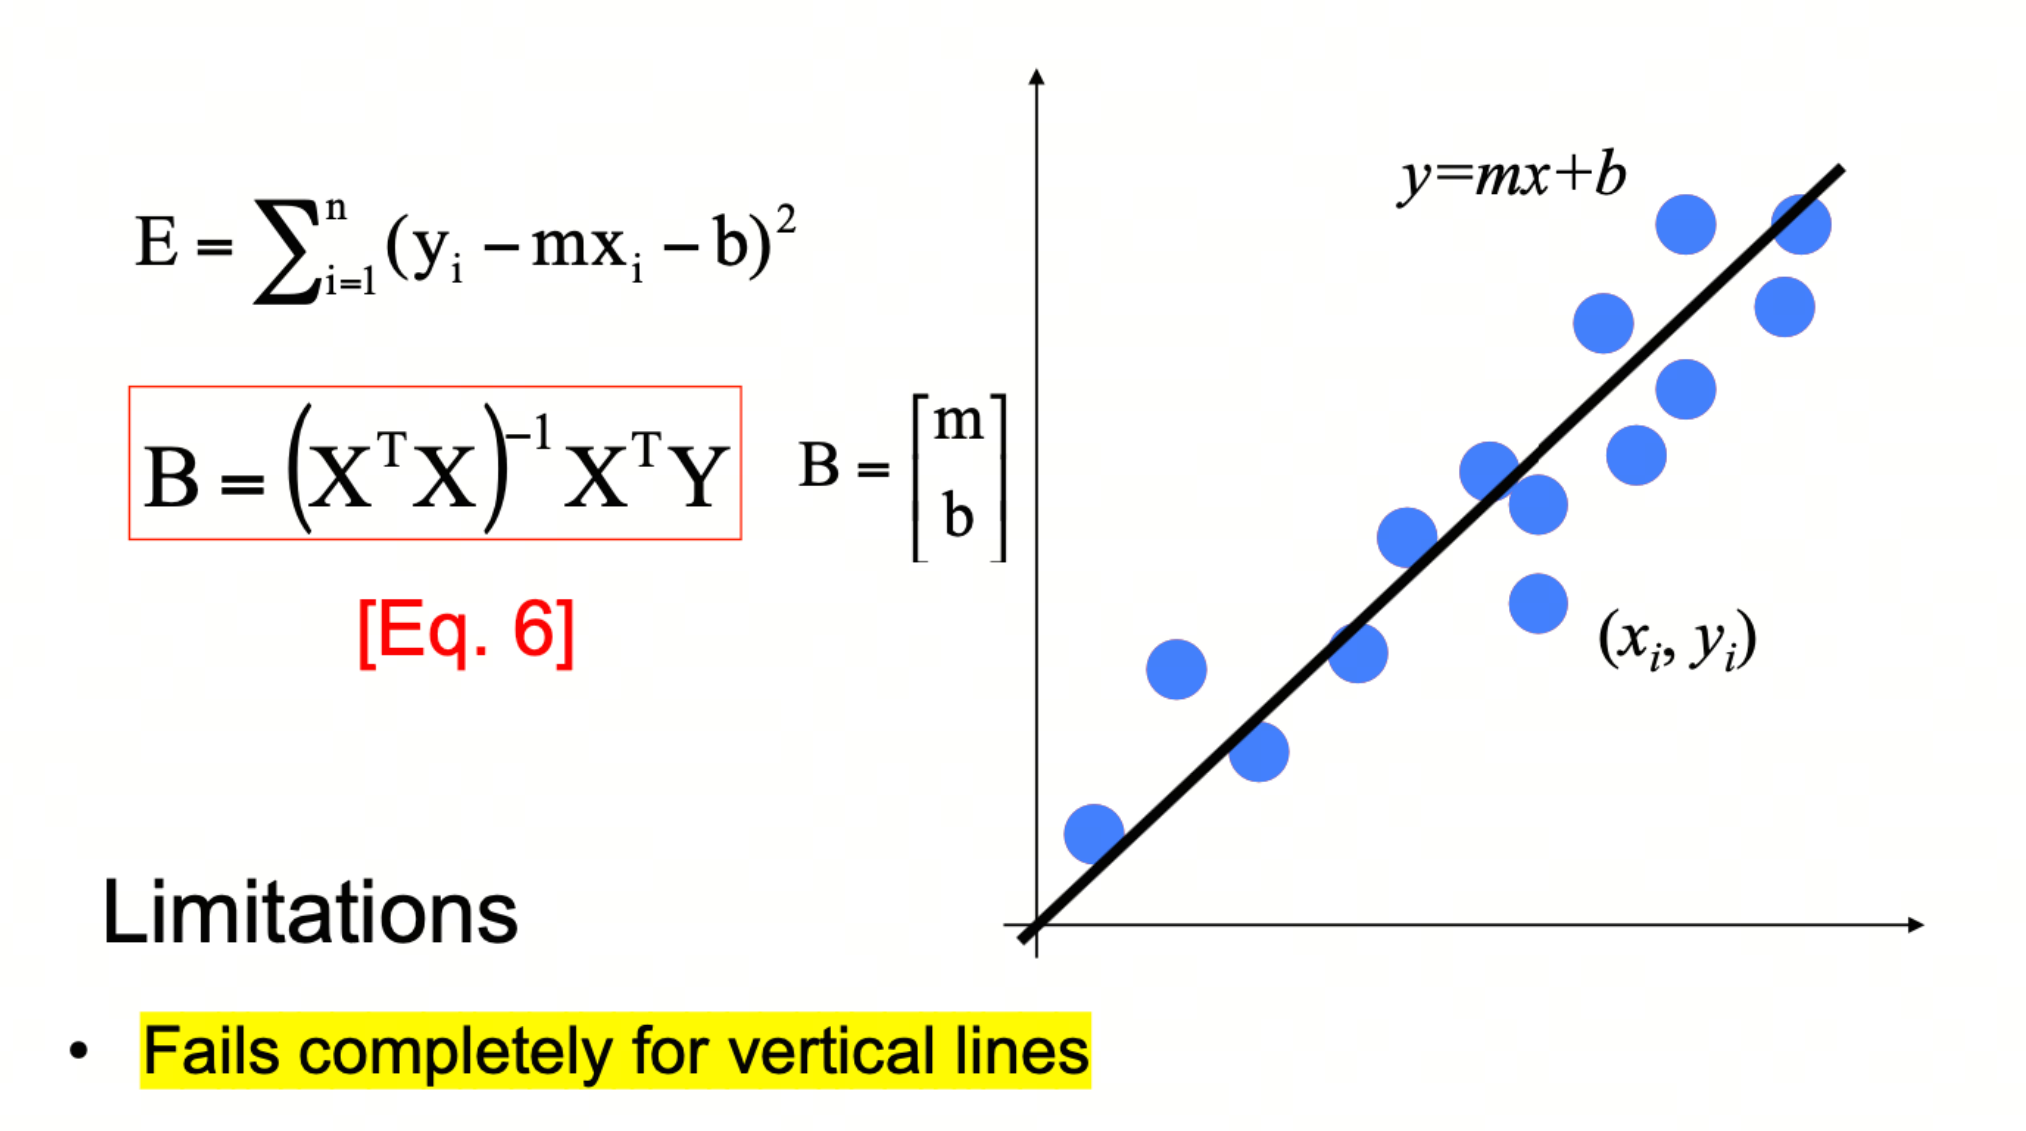
- ax+by-d=0，但是给abd同时乘一个常数，不改变直线，可能会得到000的trivial解，需要规避。
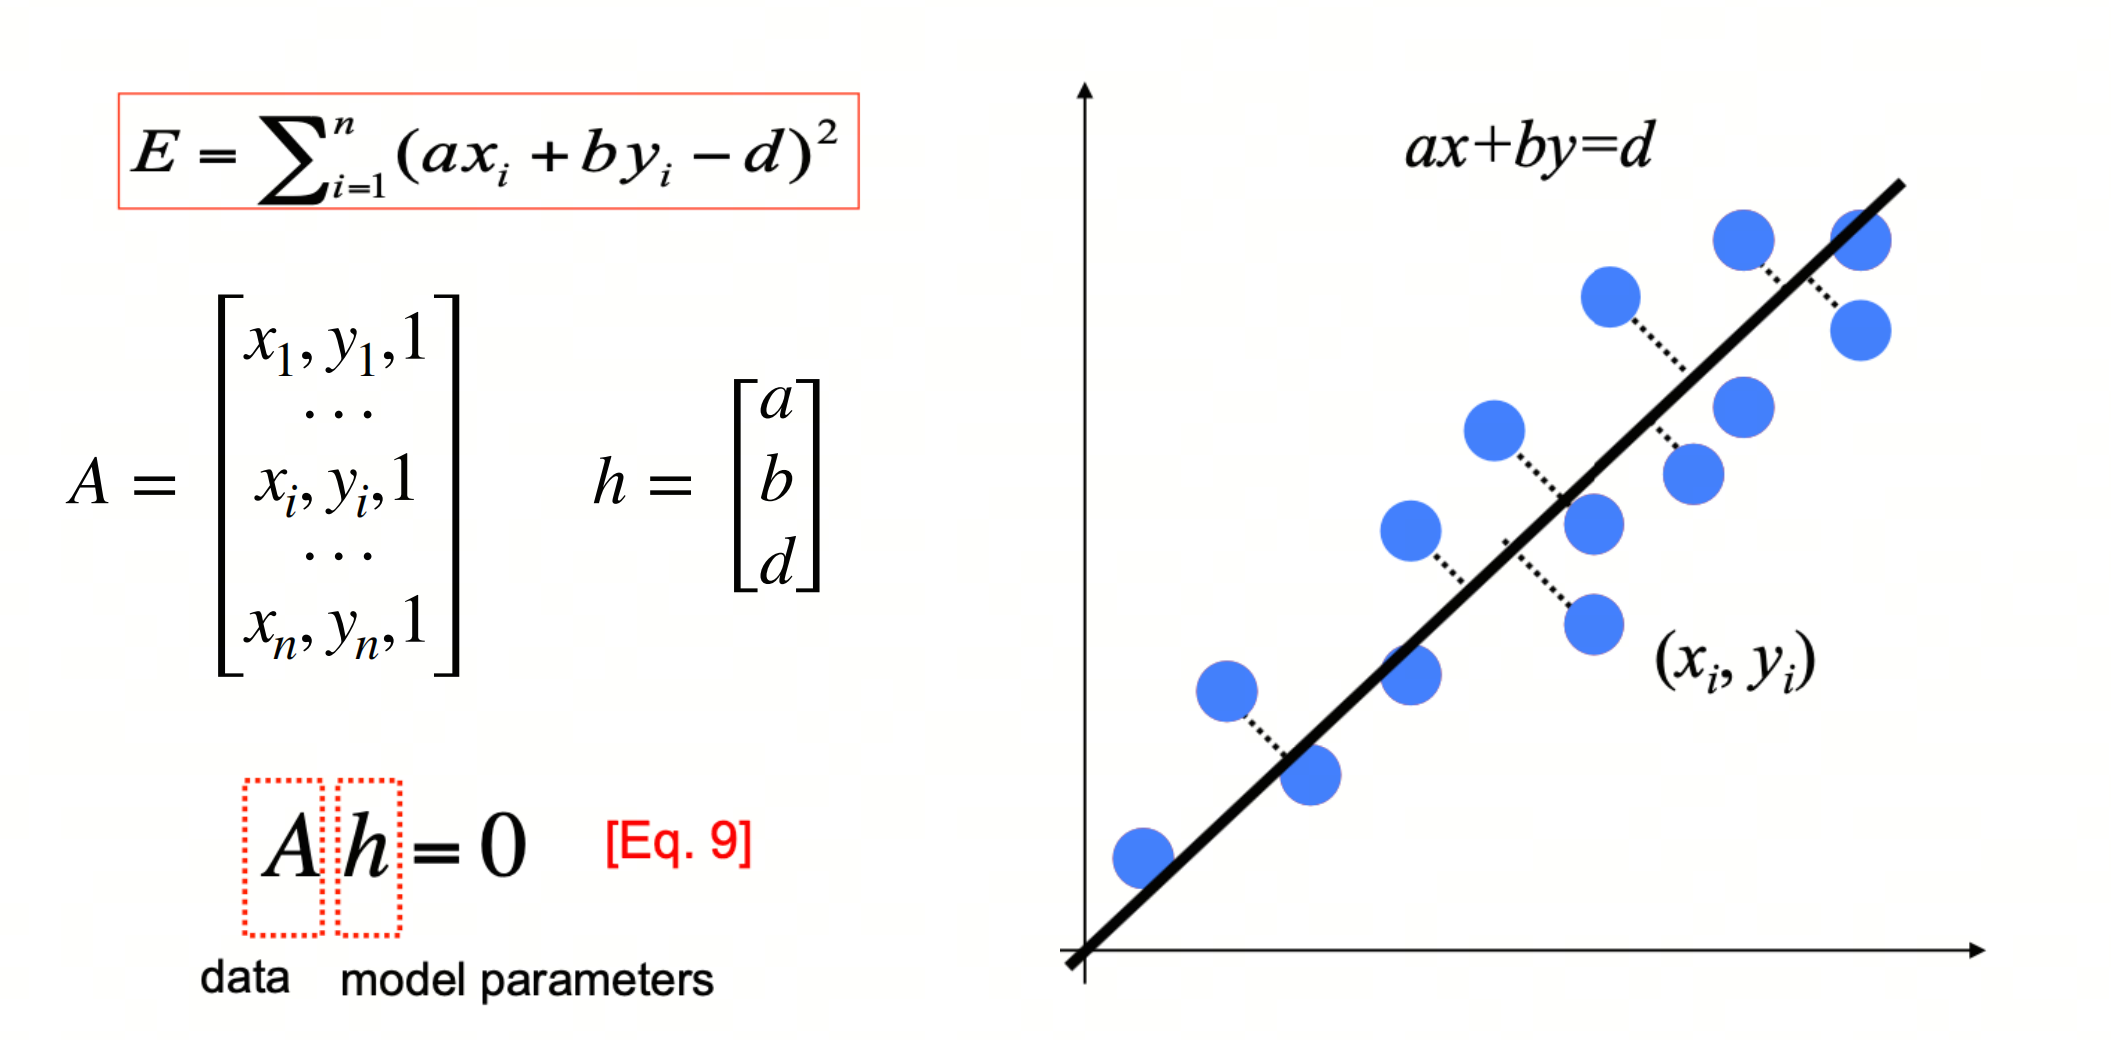
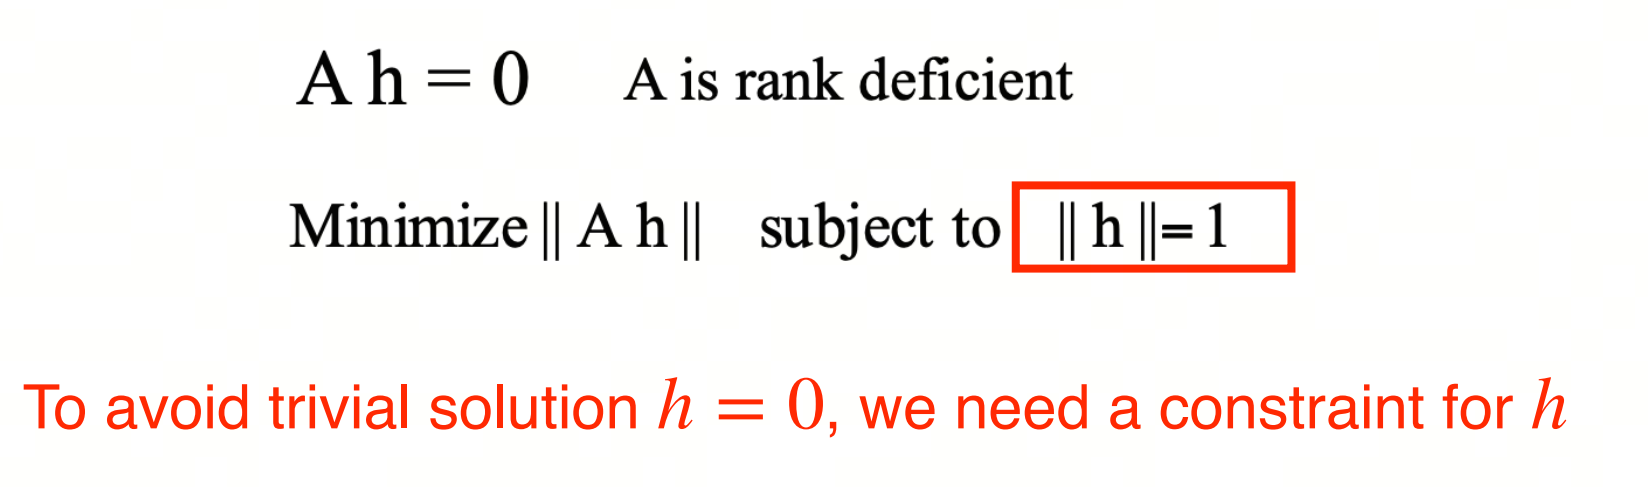

#### 1. 问题的本质

我们要解的是 $A h = 0$。
*   如果 $A$ 是一个 $m \times n$ 的矩阵。
*   如果 $A$ 是**秩亏（Rank Deficient）**的，意味着它的列向量线性相关，存在非零向量 $h$ 使得 $Ah$ 精确等于 0。
*   但在实际应用中（因为有噪声），$A$ 往往是满秩的，或者我们找不到精确的 0 解。所以我们将问题转化为优化问题：
    $$ \text{Minimize } \| A h \| \quad \text{subject to } \| h \| = 1 $$
    *   **目标：** 让 $Ah$ 的长度（范数）尽可能小（接近 0）。
    *   **约束：** $\|h\|=1$ 是为了防止 $h=0$ 这个毫无意义的平凡解（Trivial Solution）。如果不加约束，$h=0$ 肯定让目标函数最小，但这没用。

#### 2. SVD 分解回顾

对矩阵 $A$ 进行奇异值分解（SVD）：
$$ A = U \Sigma V^T $$

其中：
*   $U$ 是 $m \times m$ 的正交矩阵（左奇异向量）。
*   $\Sigma$ 是 $m \times n$ 的对角矩阵，对角线上的元素是**奇异值** $\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_n \ge 0$。
*   $V$ 是 $n \times n$ 的正交矩阵（右奇异向量），它的列向量 $v_1, v_2, \dots, v_n$ 构成了 $n$ 维空间的一组基。

#### 3. 推导过程：为什么解是 $V$ 的最后一列？

我们要最小化 $\| A h \|$。将 SVD 代入：

$$ \| A h \| = \| U \Sigma V^T h \| $$

**关键性质：** 正交矩阵（$U$ 和 $V$）乘法不改变向量的欧几里得范数（长度）。即 $\| U x \| = \| x \|$。
所以，我们可以把 $U$ 去掉，不影响最小化结果：

$$ \| A h \| = \| \Sigma (V^T h) \| $$

令 $y = V^T h$。
因为 $V$ 是正交矩阵，且我们要满足约束 $\| h \| = 1$，那么：
$$ \| y \| = \| V^T h \| = \| h \| = 1 $$

现在问题转化成了关于 $y$ 的优化问题：
$$ \text{Minimize } \| \Sigma y \| \quad \text{subject to } \| y \| = 1 $$

展开来看，$\Sigma$ 是对角矩阵，对角线元素为 $\sigma_i$：
$$ \| \Sigma y \|^2 = (\sigma_1 y_1)^2 + (\sigma_2 y_2)^2 + \dots + (\sigma_n y_n)^2 $$

我们要让这个和最小，同时满足 $y_1^2 + y_2^2 + \dots + y_n^2 = 1$。
显然，策略是把所有的“权重”都分配给**最小的奇异值** $\sigma_n$ 对应的项。

假设奇异值是从大到小排列的（$\sigma_1 \ge \dots \ge \sigma_n$）：
*   我们要让 $y_n = 1$。
*   其他 $y_1, \dots, y_{n-1}$ 全部为 0。
*   这样 $\| \Sigma y \|^2 = \sigma_n^2$，这是能达到的最小值。

**还原回 $h$：**
既然最优的 $y = [0, 0, \dots, 1]^T$（第 $n$ 个位置是 1），
根据 $y = V^T h$，也就是 $h = V y$。
这意味着 $h$ 等于矩阵 $V$ 乘以向量 $[0, \dots, 1]^T$。
**结论：$h$ 就是矩阵 $V$ 的最后一列（对应最小奇异值 $\sigma_n$ 的右奇异向量）。**

---

#### 4. 总结

**利用 SVD 求解 $Ah=0$**

*   **场景**：求解齐次线性方程组，或寻找矩阵 $A$ 的零空间（Null Space）。
*   **步骤**：
    1.  对矩阵 $A$ 进行 SVD 分解：$A = U \Sigma V^T$。
    2.  找到**最小的奇异值** $\sigma_{min}$（即 $\Sigma$ 对角线上最后一个元素）。
    3.  取出 $V$ 矩阵中**对应**于 $\sigma_{min}$ 的那一列（通常是 $V$ 的最后一列）。
    4.  这一列向量就是所求的解 $h$。

**直观理解**
*   **如果 $A$ 是秩亏的（Rank Deficient）：** 理论上存在精确解使得 $Ah=0$。此时最小奇异值 $\sigma_n = 0$。$V$ 的最后一列就是 $A$ 的零空间基向量。
*   **如果数据有噪声（近似解）：** 最小奇异值 $\sigma_n$ 很小但不为 0。此时 $V$ 的最后一列是使得 $\|Ah\|$ 最小的“最小二乘解”。

### 损失函数的选择

**损失函数（Loss Function）的选择，本质上就是你对数据噪声分布的假设。**

#### 1. 核心逻辑：从“概率”到“Loss”

我们在训练模型时，目标是让模型的预测值 $\hat{y}$ 尽可能接近真实值 $y$。
也就是误差 $\epsilon = y - \hat{y}$ 尽可能小。

但是，误差 $\epsilon$ 到底长什么样？我们需要假设它符合某种**概率分布**。

*   **最大似然估计的思想：** 我们要找到一组模型参数，使得**当前观测到的这些数据出现的概率（Likelihood）最大**。

---

#### 2. 第一种情况：假设误差符合【高斯分布】 $\rightarrow$ 对应 L2 Loss

##### 为什么假设是高斯分布？
根据中心极限定理，很多独立随机因素叠加后的噪声通常符合高斯分布（正态分布）。这是最常见的假设。前面最小二乘就是基于这个。

##### 数学推导（逻辑链条）：
1.  **高斯分布公式：** 误差 $\epsilon$ 的概率密度函数是：
    $$ P(\epsilon) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left( - \frac{\epsilon^2}{2\sigma^2} \right) $$
    注意看指数部分：是 **$\epsilon^2$（误差的平方）**。

2.  **最大化概率（Likelihood）：** 假设我们有 $N$ 个数据点，它们同时发生的总概率是每个人概率的乘积：
    $$ L = \prod_{i=1}^{N} P(\epsilon_i) \propto \prod_{i=1}^{N} \exp(-\epsilon_i^2) $$

3.  **取对数（Log-Likelihood）：** 连乘很难算，我们取对数（$\log$），把乘号变成加号。因为 $\log(\exp(x)) = x$，所以：
    $$ \log L = \sum_{i=1}^{N} (-\epsilon_i^2) = - \sum_{i=1}^{N} \epsilon_i^2 $$

4.  **转化为最小化问题：** 机器学习的目标是**最小化 Loss**。
    *   我们要让 $\log L$ 最大（概率最大）。
    *   这就等价于让 $- \sum \epsilon_i^2$ 最大。
    *   也就等价于让 $\sum \epsilon_i^2$ **最小**。

**结论：** $\sum (y - \hat{y})^2$ 正是 **L2 Loss (MSE, 均方误差)**。
所以，**用 L2 Loss 等价于假设噪声是高斯分布。**

##### 为什么怕 Outlier（异常值）？
看公式里的 **平方 $\epsilon^2$**。
*   如果正常误差是 1，平方后是 1。
*   如果来了一个异常值（Outlier），误差是 10，平方后变成 **100**。
*   **后果：** 模型会被这个巨大的 100 吓坏，为了讨好这个异常点，模型会剧烈调整参数，导致整体拟合效果变差。**L2 Loss 对异常值非常敏感。**

---

#### 3. 第二种情况：假设误差符合【拉普拉斯分布】 $\rightarrow$ 对应 L1 Loss

##### 什么是拉普拉斯分布？
它也叫“双指数分布”。它的形状像高斯分布，但是**峰值更尖，尾巴更厚**（意味着出现大误差的概率比高斯分布要高）。

##### 数学推导：
1.  **拉普拉斯分布公式：**
    $$ P(\epsilon) = \frac{1}{2b} \exp\left( - \frac{|\epsilon|}{b} \right) $$
    注意看指数部分：是 **$|\epsilon|$（误差的绝对值）**。

2.  **取对数（Log-Likelihood）：** 同样的操作，连乘变相加，$\log$ 吃掉 $\exp$：
    $$ \log L = \sum_{i=1}^{N} (-|\epsilon_i|) = - \sum_{i=1}^{N} |\epsilon_i| $$

3.  **转化为最小化问题：**
    *   让 $\log L$ 最大 $\rightarrow$ 让 $\sum |\epsilon_i|$ **最小**。

**结论：** $\sum |y - \hat{y}|$ 正是 **L1 Loss (MAE, 平均绝对误差)**。
所以，**用 L1 Loss 等价于假设噪声是拉普拉斯分布。**

##### 为什么不怕 Outlier？
看公式里的 **绝对值 $|\epsilon|$**。
*   如果正常误差是 1，绝对值是 1。
*   如果来了一个异常值，误差是 10，绝对值只是 **10**。
*   **后果：** 相比于 L2 的 100 倍惩罚，L1 只是线性惩罚。模型不会为了一个异常点而“发疯”，它会选择忽略这个异常点，保证大多数点的拟合效果。**L1 Loss 对异常值更鲁棒（Robust）。**

---

#### 总结

| 特性 | **高斯分布 (Gaussian)** | **拉普拉斯分布 (Laplace)** |
| :--- | :--- | :--- |
| **概率密度公式特征** | $\exp(-x^2)$ | $\exp(-|x|)$ |
| **对应的 Loss** | **L2 Loss (MSE)** <br> $\sum (y - \hat{y})^2$ | **L1 Loss (MAE)** <br> $\sum |y - \hat{y}|$ |
| **对异常值 (Outlier)** | **敏感** (因为平方放大了大误差) | **鲁棒** (因为绝对值只是线性增长) |
| **适用场景** | 数据干净，噪声符合正态分布 | 数据脏，有很多异常值 |
| **几何意义** | 让预测值靠近真实值的“重心” | 让预测值靠近真实值的“中位数” |

**老师的那段话翻译过来就是：**
“同学们，当我们用 L2 Loss 时，其实我们潜意识里假设了数据噪声是高斯分布。但是！如果数据里有 Outlier（异常值），高斯分布的假设就不成立了（因为平方项惩罚太重），这时候 L2 Loss 就不好用了。如果数据很脏，我们可以假设噪声是拉普拉斯分布，这时候就应该用 L1 Loss。”


## 补充说明
### CV中的“卷积” vs. 数学中的卷积

#### 1. 核心区别：核是否翻转 (The Kernel Flip)
这是两者最根本的数学定义区别。

*   **数学卷积 (Convolution)：**
    *   **定义：** 在滑动窗口计算之前，必须先将卷积核（Kernel/Filter）进行**翻转（Flip）**（即旋转180度）。
    *   **公式特征：** 索引是相减的。
        *   1D: $(f * g)(n) = \sum f(m) \cdot g(\mathbf{n - m})$
        *   2D: $(f * g)(i, j) = \sum \sum f(\mathbf{i - m, j - n}) \cdot g(m, n)$
    *   **直观理解：** 就像把印章盖在纸上之前，先把印章反过来拿。

*   **CV中的“卷积” (实为 Cross-Correlation / 互相关)：**
    *   **定义：** 核**不需要翻转**，直接拿着核在图像上滑动。
    *   **公式特征：** 索引是相加的（或者理解为直接对应位置相乘）。
        *   1D: $(f \star g)(n) = \sum f(m) \cdot g(\mathbf{m + n})$
        *   2D: $(f \star g)(i, j) = \sum \sum f(\mathbf{i + m, j + n}) \cdot g(m, n)$
    *   **直观理解：** 就像拿着一个模板（Template）直接在图片上比对，看哪里长得像。

#### 2. 数学性质的差异 (基于PPT 2)
由于缺少了“翻转”这一步，互相关（Correlation）失去了一些数学卷积拥有的优良性质。

| 性质 | 数学卷积 (Convolution) | CV互相关 (Correlation) | 解释 |
| :--- | :---: | :---: | :--- |
| **交换律 (Commutativity)** | ✅ 满足 ($f*g = g*f$) | ❌ **不满足** | 卷积核翻转后，谁卷谁都一样；但互相关不翻转，顺序很重要。 |
| **结合律 (Associativity)** | ✅ 满足 | ❌ **不满足** | 多个滤波器串联时，卷积可以合并，互相关不行。 |
| **分配律 (Distributivity)** | ✅ 满足 | ❌ **不满足** | 并联滤波器时，卷积可以合并，互相关不行。 |
| **直觉/用途** | **滤波 (Filter)** | **模板匹配 (Template Matching)** | 卷积用于信号处理（如去噪）；互相关用于寻找图像中相似的模式。 |

#### 3. 为什么CV里可以“张冠李戴”？
既然CV里用的其实是互相关，为什么还要叫它“卷积层 (Convolutional Layer)”？而且不影响使用？

*   **原因：参数是学出来的 (Learned Parameters)。**
    *   在传统的信号处理中，卷积核 $g$ 是人为设计好的（比如高斯模糊核、Sobel算子），这时候翻转与否对结果影响巨大。
    *   在深度学习中，卷积核 $g$ 的权重是通过反向传播**学习**得到的。
    *   **结论：** 如果网络需要数学卷积的效果，它只需要学习到“翻转后”的权重即可。对于神经网络来说，学习一个核 $W$ 和学习它的翻转版本 $Flip(W)$ 难度是一样的，表达能力也是等价的。因此，为了计算效率（少一步翻转操作），CV领域直接沿用了互相关的计算方式，但习惯上仍称之为“卷积”。

#### 4. 总结 (Key Takeaway)
*   **操作层面：** CV里的卷积 = **不翻转**的滑动窗口乘加运算。
*   **本质层面：** 它实际上是**互相关 (Cross-Correlation)**。
*   **影响：** 虽然它不具备数学卷积的交换律等性质，但在特征提取（Feature Extraction）和模板匹配的任务中，这种差异被参数学习过程抵消了，**不影响模型的最终性能**。

---

PPT提到的 $\mathcal{F}(\bar{f})$ 是指傅里叶变换中的复共轭。在频域中，卷积定理告诉我们：
*   时域卷积 = 频域乘积：$\mathcal{F}(f * g) = \mathcal{F}(f) \cdot \mathcal{F}(g)$
*   时域互相关 = 频域乘积（其中一个取共轭）：$\mathcal{F}(f \star g) = \mathcal{F}(f) \cdot \overline{\mathcal{F}(g)}$
这也从频域角度证明了两者相差一个“共轭/翻转”的操作。

### **卷积操作的工程实现优化**。

它的核心思想是：**“虽然卷积在逻辑上是滑动窗口，但在代码实现上，我们要把它强行变成矩阵乘法。”**

#### 为什么要这么做？
*   **痛点：** 如果直接用 `for` 循环去写卷积（即：移动窗口 -> 对应元素相乘 -> 求和），计算效率极低，而且 GPU 非常不擅长处理这种复杂的逻辑跳转和循环。
*   **优势：** GPU 最擅长做**矩阵乘法（GEMM, General Matrix Multiplication）**。现有的线性代数库（如 cuBLAS）对矩阵乘法做了极致的优化。
*   **核心策略：** 把“滑动窗口”的操作，转化为“大矩阵 $\times$ 大矩阵”的操作。
*   
#### 方法一（首推）：im2col

##### 具体步骤（4步走）

假设我们有一个 $K \times K$ 的卷积核，和一个 $H \times W$ 的输入图像。

*   **Step 1: 卷积核扁平化 (Kernel Flattening)**
    *   把 $K \times K$ 的卷积核“拉直”，变成一个行向量。
    *   维度变化：$K \times K \longrightarrow 1 \times K^2$。
    *   *注：如果有多个卷积核，这里就会变成多行。*

*   **Step 2: im2col 变换 (这是最关键的一步)**
    *   **操作：** 想象卷积核在图像上滑动。每滑动到一个位置，就把那个位置覆盖的 $K \times K$ 区域抠出来（Patch）。
    *   **重排：** 把这个抠出来的 $K \times K$ 小方块拉直成一个**列向量**（大小 $K^2 \times 1$）。
    *   **拼接：** 把所有位置的列向量，横向拼在一起，组成一个巨大的矩阵。
    *   **维度变化：** 图像 $H \times W \longrightarrow K^2 \times N$。
        *   其中 $N = H_{out} \times W_{out}$（即输出特征图有多少个像素点，就有多少列）。
    *   *注意：这一步会有大量的数据重复，因为滑动窗口是有重叠的，同一个像素会被复制到不同的列中。*

*   **Step 3: 矩阵乘法 (GEMM)**
    *   现在我们要算卷积了。
    *   **算式：** (Step 1 的核) $\times$ (Step 2 的图)。
    *   **维度：** $(1 \times K^2) \times (K^2 \times N) \longrightarrow 1 \times N$。
    *   这一步一次性算出了所有位置的卷积结果，结果是一个长向量。

*   **Step 4: 输出重塑 (Output Reconstruction)**
    *   把算出来的 $1 \times N$ 的长向量，重新折叠（Reshape）回二维矩阵。
    *   **维度：** $1 \times N \longrightarrow H_{out} \times W_{out}$。
    *   这就得到了最终的输出特征图（Feature Map）。

---

#### 法二：Toeplitz 矩阵

**简短回答：不完全是“一件事”，但它们在数学本质上是等价的，都是把卷积转化为矩阵乘法。PPT 里讲的是 `im2col` 方法，而 Toeplitz 是另一种实现路径。**

##### 1. 它们的共同点
*   **目的相同：** 都是为了利用 $Y = WX$ 这种矩阵乘法形式来计算卷积。
*   **数学等价：** 无论用哪种方法，算出来的结果是一模一样的。

##### 2. 它们的区别（核心区别在于“谁被展开了”）

| 特性 | **PPT中的方法 (im2col + GEMM)** | **Toeplitz 矩阵方法** |
| :--- | :--- | :--- |
| **操作对象** | **展开输入图像 (Input)** | **展开卷积核 (Kernel)** |
| **具体做法** | 把输入图像切成很多重叠的块，拉直拼成大矩阵（如PPT Step 2）。卷积核保持较小。 | 把卷积核构造成一个巨大的、稀疏的 **Toeplitz 矩阵**（每一行是上一行的移位）。输入图像拉直成向量。 |
| **内存占用** | **高**。因为输入图像的像素被大量复制（重叠区域）。 | **极高**。Toeplitz 矩阵非常大且稀疏，显存占用通常比 im2col 更夸张。 |
| **深度学习中的应用** | **主流**。如 Caffe, 早期 PyTorch/TensorFlow 底层常用。因为 GEMM 库优化得极好。 | **较少用于训练**。更多用于理论推导或信号处理。因为构造那个巨大的矩阵太麻烦且浪费内存。 |

##### 3. 举个简单的例子
假设输入是 $[1, 2, 3, 4]$，卷积核是 $[a, b]$。

*   **im2col (PPT的方法):**
    构造输入矩阵（把输入展开）：
    $$
    \begin{bmatrix} 1 & 2 & 3 \\ 2 & 3 & 4 \end{bmatrix}
    $$
    卷积核是 $[a, b]$。
    计算：$[a, b] \times \begin{bmatrix} 1 & 2 & 3 \\ 2 & 3 & 4 \end{bmatrix}$。

*   **Toeplitz 方法:**
    构造 Toeplitz 矩阵（把核展开）：
    $$
    \begin{bmatrix} a & b & 0 & 0 \\ 0 & a & b & 0 \\ 0 & 0 & a & b \end{bmatrix}
    $$
    输入向量是 $[1, 2, 3, 4]^T$。
    计算：$\text{Toeplitz} \times [1, 2, 3, 4]^T$。

**总结：**
PPT 讲的是目前深度学习框架中最常用的 **im2col** 实现方式。虽然它和 Toeplitz 矩阵在数学上都能实现“卷积转乘法”，但 im2col 更适合 GPU 的并行计算架构，且实现起来更直观（只是搬运数据），所以成为了工业界的标准做法。


### 传统 Line Detection 的问题

虽然我们在前面提到了 L2 Loss（可微）和 SVD（数学上可微），但当把它们组合成**“RANSAC + 最小二乘/SVD”**这套完整的传统求解逻辑时，它就变成了不可微的。

这意味着你**无法使用梯度下降（Backpropagation）**来直接优化这套流程中的参数。

以下是具体的“不可微”环节拆解：

#### 1. 核心原因：RANSAC 充满了离散操作
RANSAC 的流程是：随机采样 $\rightarrow$ 拟合模型 $\rightarrow$ 统计内点数量 $\rightarrow$ 选择最佳模型。这其中每一步都“阻断”了梯度的流动：

*   **随机采样 (Random Sampling)：**
    *   从数据集中随机挑 $s$ 个点。这是一个离散的概率事件，没有连续的参数可供求导。
*   **内点/外点判定 (Hard Thresholding)：**
    *   这是最关键的不可微点。判断一个点是不是内点，通常使用一个硬性阈值：
        $$ \text{is\_inlier} = \begin{cases} 1 & \text{if } |error| < \tau \\ 0 & \text{if } |error| \ge \tau \end{cases} $$
    *   这是一个**阶跃函数（Step Function）**。
    *   在 $\tau$ 处导数不存在，在其他地方导数都是 0。这意味着误差变小一点点（只要没跨过阈值），对结果没有任何影响，梯度无法传递。
*   **计数 (Counting)：**
    *   我们要最大化内点的数量：$N_{inliers} = \sum \text{is\_inlier}$。
    *   这是一个离散的计数操作，导数为 0。
*   **模型选择 (Argmax)：**
    *   最后我们要从 $N$ 次尝试中选出内点最多的那个模型：$Model_{best} = \text{argmax}_k (N_{inliers}^{(k)})$。
    *   `argmax` 操作也是不可微的离散操作。

#### 2. SVD 的角色
虽然 SVD 分解在数学理论上是可以求导的（有相关的矩阵微积分公式），但在传统 CV 流程中：
*   SVD 是作为**最后一步的代数求解器**使用的。
*   它的输入数据（那些被 RANSAC 筛选出来的“内点”）已经是经过上述不可微操作筛选后的结果。
*   因此，整个 **Input $\rightarrow$ RANSAC $\rightarrow$ SVD $\rightarrow$ Output** 的链路是断裂的，无法端到端地求导。

#### 3. 与深度学习的对比（帮助理解）

*   **深度学习（可微）：**
    *   逻辑：预测值偏了 $\rightarrow$ 计算 Loss $\rightarrow$ **求导得到梯度** $\rightarrow$ 告诉参数“往哪个方向微调能变小”。
    *   特点：平滑、连续、有方向指引。

*   **本节课的逻辑（不可微）：**
    *   逻辑：随机猜一组参数 $\rightarrow$ 看看有多少个点同意（计数） $\rightarrow$ 如果同意的多，就保留；否则扔掉重猜。
    *   特点：**没有梯度指引**。模型不知道“稍微改动一下参数会不会让内点变多”，它只能靠“盲猜”（随机采样）来碰运气。

这套逻辑不可微，是**传统几何方法（基于优化、搜索、代数解）与深度学习方法（基于梯度下降）的本质区别**。这也正是目前计算机视觉研究的一个热点方向：**如何让 RANSAC 变得可微（Differentiable RANSAC）**，从而能把它嵌入到神经网络中进行端到端训练。